In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [ ]:
enrol_df = pd.read_csv("../Data/Feature_Data/feature_enrolment.csv")
demo_df = pd.read_csv("../Data/Feature_Data/feature_demographic.csv")
bio_df = pd.read_csv("../Data/Feature_Data/feature_biometric.csv")
demo_bio_df = pd.read_csv("../Data/Feature_Data/feature_demo_bio_combined.csv")

adv_enrol_df = pd.read_csv("../Data/Advanced_Feature_Data/advanced_feature_enrolment.csv")
adv_demo_bio_df = pd.read_csv("../Data/Advanced_Feature_Data/advanced_feature_demo_bio.csv")


In [3]:
datasets = {
    "Enrolment Features": enrol_df,
    "Demographic Features": demo_df,
    "Biometric Features": bio_df,
    "Demographic + Biometric Combined": demo_bio_df,
    "Advanced Enrolment Features": adv_enrol_df,
    "Advanced Demo-Bio Features": adv_demo_bio_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Enrolment Features: (320114, 17)
Demographic Features: (2050691, 13)
Biometric Features: (1843901, 13)
Demographic + Biometric Combined: (1631503, 23)
Advanced Enrolment Features: (994925, 24)
Advanced Demo-Bio Features: (1631503, 25)


In [4]:
for name, df in datasets.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())


Enrolment Features columns:
['date', 'state_clean', 'district_clean', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'is_weekend', 'total_enrolments', 'child_enrolments', 'adult_ratio', 'child_share']

Demographic Features columns:
['date', 'state_clean', 'district_clean', 'pincode', 'demo_age_5_17', 'demo_age_17_', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'is_weekend', 'total_demographic_updates']

Biometric Features columns:
['date', 'state_clean', 'district_clean', 'pincode', 'bio_age_5_17', 'bio_age_17_', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'is_weekend', 'total_biometric_updates']

Demographic + Biometric Combined columns:
['date', 'state_clean', 'district_clean', 'pincode', 'demo_age_5_17', 'demo_age_17_', 'year_demo', 'month_demo', 'quarter_demo', 'week_of_year_demo', 'day_of_week_demo', 'is_weekend_demo', 'total_demographic_updates', 'bio_age_5_17', 'bio_age_17_', 'year_bio'

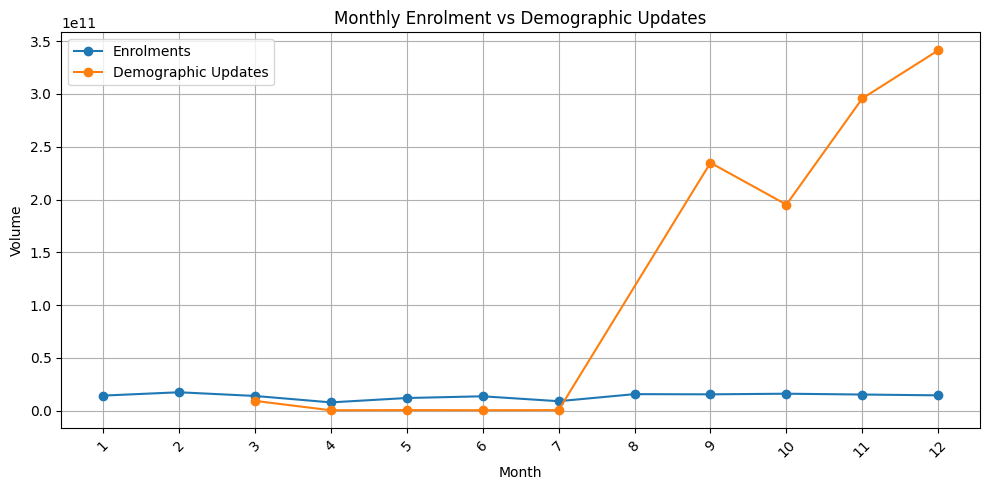

In [5]:
enrol_monthly = enrol_df.groupby("month").sum(numeric_only=True)
demo_monthly = demo_df.groupby("month").sum(numeric_only=True)

plt.plot(
    enrol_monthly.index.astype(str),
    enrol_monthly.iloc[:, 0],
    label="Enrolments",
    marker="o"
)

plt.plot(
    demo_monthly.index.astype(str),
    demo_monthly.iloc[:, 0],
    label="Demographic Updates",
    marker="o"
)

plt.title("Monthly Enrolment vs Demographic Updates")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


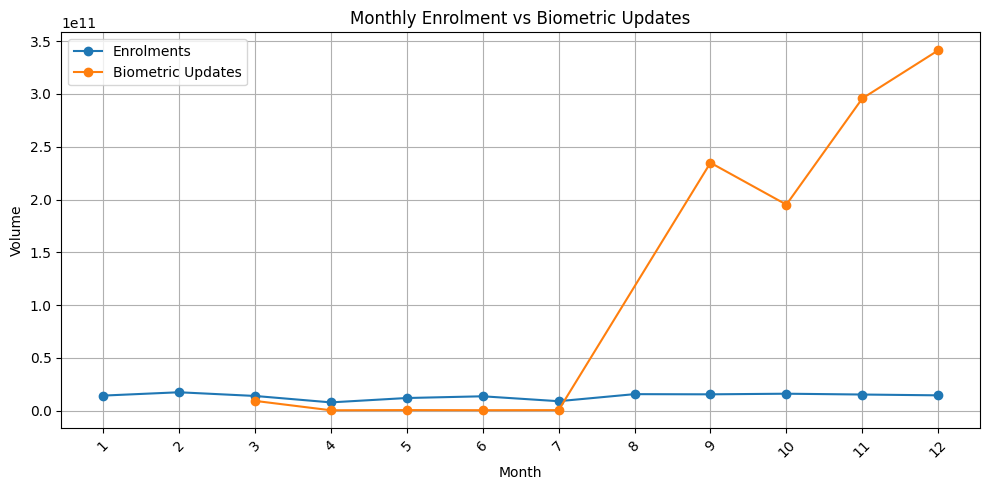

In [11]:
enrol_monthly = enrol_df.groupby("month").sum(numeric_only=True)
bio_monthly = bio_df.groupby("month").sum(numeric_only=True)
plt.plot(
    enrol_monthly.index.astype(str),
    enrol_monthly.iloc[:, 0],
    label="Enrolments",
    marker="o"
)

plt.plot(
    demo_monthly.index.astype(str),
    demo_monthly.iloc[:, 0],
    label="Biometric Updates",
    marker="o"
)

plt.title("Monthly Enrolment vs Biometric Updates")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



Enrolment spike followed by update spike → normal operational processing delay

Persistent enrolment dominance → backlog accumulation or capacity limits

Updates exceeding enrolments → backlog clearance or legacy data correction

Biometric lag larger than demographic lag → infrastructure or staffing constraints

This subsection aggregates enrolment, demographic update, and biometric update volumes at the regional level.
The goal is to compare relative intensity of enrolment versus updates across regions, without assuming row-level alignment.

In [ ]:
enrol_region = enrol_df.groupby(
    ["state_clean", "district_clean"]
).sum(numeric_only=True).reset_index()

demo_region = demo_df.groupby(
    ["state_clean", "district_clean"]
).sum(numeric_only=True).reset_index()
bio_region = bio_df.groupby(
    ["state_clean", "district_clean"]
).sum(numeric_only=True).reset_index()


Regions with high enrolment but relatively low update activity may indicate
new enrolment drives, infrastructure constraints, or pending update backlogs.

In [ ]:
region_compare = enrol_region.merge(
    demo_region,
    on=["state_clean", "district_clean"],
    how="inner",
    suffixes=("_enrol", "_demo")
).merge(
    bio_region,
    on=["state_clean", "district_clean"],
    how="inner"
)
numeric_cols = region_compare.select_dtypes(include="number").columns
region_compare["update_to_enrol_ratio"] = (
    region_compare[numeric_cols[1]] + region_compare[numeric_cols[2]]
) / region_compare[numeric_cols[0]]
region_compare.sort_values(
    by="update_to_enrol_ratio",
    ascending=True
).head(10)

,state_clean,district_clean,pincode_enrol,age_0_5,age_5_17,age_18_greater,year_enrol,month_enrol,quarter_enrol,week_of_year_enrol,...,pincode,bio_age_5_17,bio_age_17_,year,quarter,week_of_year,day_of_week,is_weekend,total_biometric_updates,update_to_enrol_ratio
574,Nagaland,tseminyu,2391327,0,0,5,6075,28,10,115,...,27101698,53,133,68850,128,1439,88,6,186,0.000000e+00
687,Sikkim,namchi,4422790,1,0,5,12150,39,14,154,...,3685641,0,5,10125,18,219,10,1,5,2.261016e-07
559,Mizoram,saitual,3185044,0,2,2,8100,16,7,61,...,19110323,37,40,48600,87,1040,52,3,77,6.279348e-07
552,Mizoram,khawzawl,5574170,3,2,4,14175,52,20,210,...,6370540,6,2,16200,28,328,27,2,8,8.969945e-07
74,Assam,bajali,9376047,7,3,2,24300,76,29,302,...,17189297,6,17,44550,80,956,56,5,23,1.066548e-06
533,Manipur,pherzawl,795121,0,1,0,2025,10,4,41,...,1593749,2,0,4050,8,102,12,2,2,1.257670e-06
58,Arunachal Pradesh,leparada,791101,0,1,0,2025,9,3,37,...,18195323,34,2,46575,89,1023,69,5,36,1.264061e-06
147,Bihar,samstipur,22900051,13,16,0,54675,155,60,611,...,139097431,13,182,332100,612,7142,469,39,195,1.266373e-06
117,Bihar,bhabua,10655377,5,9,0,26325,76,29,301,...,24595203,4,29,60750,110,1280,107,10,33,1.313891e-06
2,Andaman and Nicobar Islands,nicobars,744301,1,0,0,2025,3,1,10,...,1488602,1,1,4050,7,85,1,0,2,1.343542e-06


Regions with high update activity but lower enrolment volumes often represent
legacy Aadhaar populations, data correction campaigns, or urban service centers.

In [ ]:
region_compare.sort_values(
    by="update_to_enrol_ratio",
    ascending=False
).head(10)

,state_clean,district_clean,pincode_enrol,age_0_5,age_5_17,age_18_greater,year_enrol,month_enrol,quarter_enrol,week_of_year_enrol,...,pincode,bio_age_5_17,bio_age_17_,year,quarter,week_of_year,day_of_week,is_weekend,total_biometric_updates,update_to_enrol_ratio
207,Delhi,north east delhi,10456535,5263,2682,45,192375,615,237,2452,...,41936919,77278,65818,771525,1394,16170,1125,107,143096,0.000760
669,Rajasthan,jalore,650030,296,182,13,4050,13,5,52,...,6790126,3,17,40500,80,993,66,7,20,0.000735
221,Gujarat,banas kantha,20038686,5484,6470,607,105300,189,88,704,...,84005894,59,488,441450,815,9640,608,53,547,0.000597
704,Tamil Nadu,kanchipuram,631502,264,76,11,2025,1,1,2,...,5435215,1,8,18225,36,429,29,2,9,0.000538
213,Delhi,west delhi,25750027,10093,3452,890,473850,1490,575,5926,...,94967896,71164,102078,1747575,3146,36475,2550,245,173242,0.000526
355,Karnataka,bengaluru rural,4482576,1438,729,621,16200,8,8,16,...,3372978,5,5,12150,23,268,12,0,10,0.000483
139,Bihar,pashchim champaran,33814949,5006,10622,549,81000,142,66,522,...,156372088,40,313,374625,695,8163,521,46,353,0.000462
258,Haryana,faridabad,32916815,8988,2370,273,550800,1750,673,6969,...,144621421,58976,59975,2419875,4379,50730,3551,343,118951,0.000345
202,Delhi,east delhi,19592526,4977,1732,183,360450,1113,431,4417,...,80460847,53829,68976,1480275,2672,30947,2173,209,122805,0.000342
857,Uttar Pradesh,rampur,45515565,8029,5608,254,378675,1207,465,4806,...,197900395,83353,41589,1662525,3001,34731,2438,233,124942,0.000300


This visualization highlights the most imbalanced regions to visually compare
enrolment and update volumes side by side.

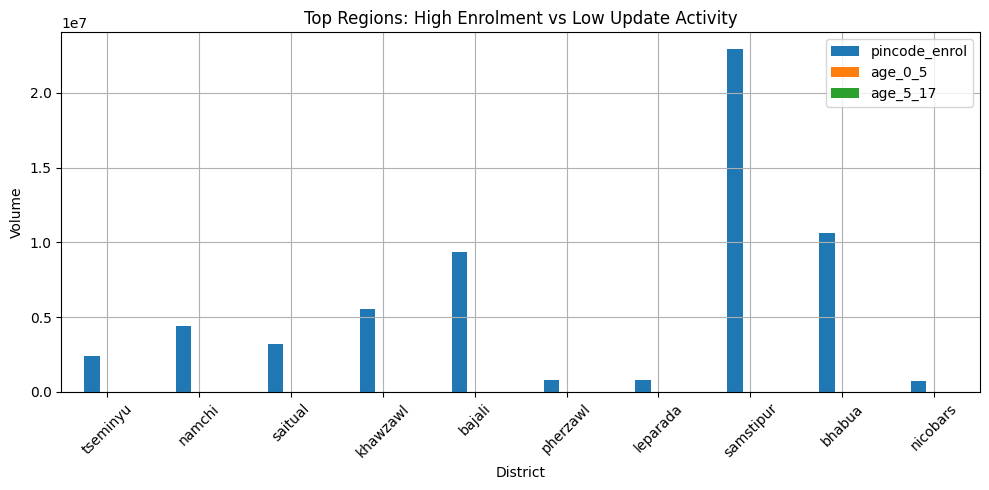

In [20]:
top_regions = region_compare.sort_values(
    by="update_to_enrol_ratio"
).head(10)

top_regions.plot(
    x="district_clean",
    y=numeric_cols[:3],
    kind="bar",
    title="Top Regions: High Enrolment vs Low Update Activity"
)

plt.xlabel("District")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


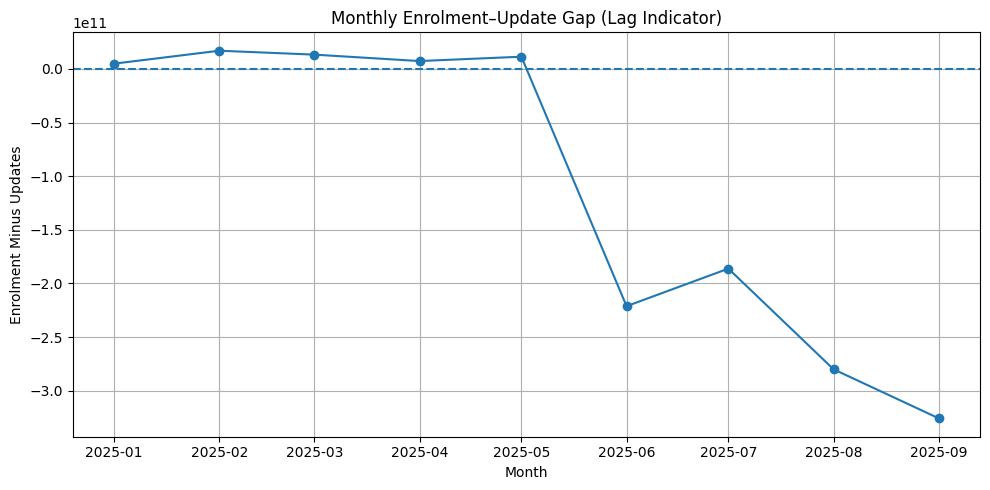

In [ ]:
enrol_monthly = enrol_df.groupby("month", as_index=False).sum(numeric_only=True)
demo_monthly = demo_df.groupby("month", as_index=False).sum(numeric_only=True)
bio_monthly = bio_df.groupby("month", as_index=False).sum(numeric_only=True)
x_month = pd.to_datetime(
    "2025-" + enrol_monthly["month"].astype(str).str.zfill(2) + "-01",
    format="%Y-%m-%d"
)
total_updates = demo_monthly.select_dtypes("number").iloc[:, 1] + bio_monthly.select_dtypes("number").iloc[:, 1]

lag_gap = enrol_monthly.select_dtypes("number").iloc[:, 1] - total_updates

plt.plot(x_month, lag_gap, marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Enrolment–Update Gap (Lag Indicator)")
plt.xlabel("Month")
plt.ylabel("Enrolment Minus Updates")
plt.tight_layout()
plt.show()

To highlight months with significant imbalance, we examine the difference between enrolment and total update volumes.

In [ ]:
print(adv_enrol_df.columns)
print(adv_demo_bio_df.columns)

Index(['date', 'state_clean', 'district_clean', 'pincode', 'age_0_5',
       'age_5_17', 'age_18_greater', 'year', 'month', 'quarter',
       'week_of_year', 'day_of_week', 'is_weekend', 'total_enrolments',
       'child_enrolments', 'adult_ratio', 'child_share',
       'enrolment_dod_change', 'enrolment_dod_pct_change',
       'enrolment_7day_mean', 'enrolment_7day_std', 'enrolment_volatility',
       'sudden_surge_flag', 'sudden_drop_flag'],
      dtype='object')
Index(['date', 'state_clean', 'district_clean', 'pincode', 'demo_age_5_17',
       'demo_age_17_', 'year_demo', 'month_demo', 'quarter_demo',
       'week_of_year_demo', 'day_of_week_demo', 'is_weekend_demo',
       'total_demographic_updates', 'bio_age_5_17', 'bio_age_17_', 'year_bio',
       'month_bio', 'quarter_bio', 'week_of_year_bio', 'day_of_week_bio',
       'is_weekend_bio', 'total_biometric_updates',
       'biometric_to_demographic_ratio', 'bio_demo_stress_ratio',
       'high_biometric_stress_flag', 'month'],
   

In [ ]:

monthly_enrol_stress = adv_enrol_df.groupby("month", as_index=False)["enrolment_volatility"].sum()
monthly_update_stress = adv_demo_bio_df.groupby("month", as_index=False)["bio_demo_stress_ratio"].sum()


NameError: name 'adv_enrol_df' is not defined

In [41]:
x_month = pd.to_datetime("2025-" + monthly_enrol_stress["month"].astype(str).str.zfill(2) + "-01", format="%Y-%m-%d")


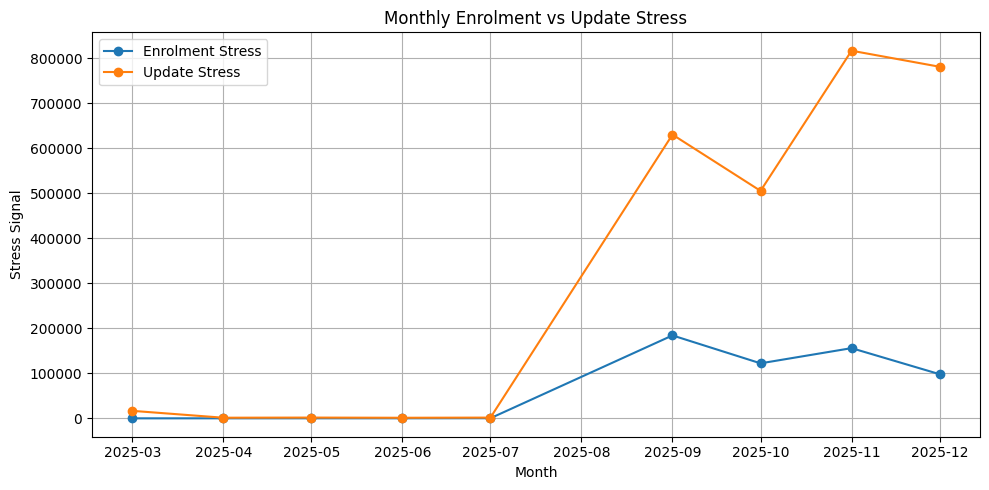

In [43]:
plt.plot(x_month, monthly_enrol_stress["enrolment_volatility"], marker="o", label="Enrolment Stress")
plt.plot(x_month, monthly_update_stress["bio_demo_stress_ratio"], marker="o", label="Update Stress")

plt.title("Monthly Enrolment vs Update Stress")
plt.xlabel("Month")
plt.ylabel("Stress Signal")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
enrol_median = monthly_enrol_stress["enrolment_volatility"].median()
update_median = monthly_update_stress["bio_demo_stress_ratio"].median()

high_stress_months = pd.DataFrame({
    "month": x_month,
    "enrol_stress": monthly_enrol_stress["enrolment_volatility"],
    "update_stress": monthly_update_stress["bio_demo_stress_ratio"]
})

high_stress_months["high_stress_flag"] = (
    (high_stress_months["enrol_stress"] > enrol_median) |
    (high_stress_months["update_stress"] > update_median)
)
high_stress_months[high_stress_months["high_stress_flag"]]

,month,enrol_stress,update_stress,high_stress_flag
5,2025-09-01,184202.835242,630255.523228,True
6,2025-10-01,122200.303955,505261.534183,True
7,2025-11-01,155947.118377,816582.610314,True
8,2025-12-01,98045.335267,780952.807330,True


Months with high enrolment volatility or high update stress ratio are likely overloaded or have backlogs

Visualization lets you pinpoint operational pressure periods

Supports decisions like resource allocation or infrastructure scaling

In [ ]:
enrol_surge = adv_enrol_df[adv_enrol_df["sudden_surge_flag"] == 1]
enrol_drop = adv_enrol_df[adv_enrol_df["sudden_drop_flag"] == 1]
update_anomaly = adv_demo_bio_df[adv_demo_bio_df["high_biometric_stress_flag"] == 1]

print("Enrolment Surges:", len(enrol_surge))
print("Enrolment Drops:", len(enrol_drop))
print("High Update Stress Flags:", len(update_anomaly))


Enrolment Surges: 268487
Enrolment Drops: 149905
High Update Stress Flags: 514423


Plot anomalies on top of monthly enrolment and update volumes to see timing and magnitude of unusual events

In [ ]:
enrol_monthly_vol = adv_enrol_df.groupby("month", as_index=False)["total_enrolments"].sum()
update_monthly_vol = adv_demo_bio_df.groupby("month", as_index=False)["total_demographic_updates"].sum()

monthly_surge = enrol_surge.groupby("month").size().reset_index(name="surge_count")
monthly_drop = enrol_drop.groupby("month").size().reset_index(name="drop_count")
monthly_update_anomaly = update_anomaly.groupby("month").size().reset_index(name="update_anomaly_count")

monthly_anomalies = pd.DataFrame({"month": range(1, 13)})
monthly_anomalies = monthly_anomalies.merge(monthly_surge, on="month", how="left") \
                                     .merge(monthly_drop, on="month", how="left") \
                                     .merge(monthly_update_anomaly, on="month", how="left")
monthly_anomalies = monthly_anomalies.fillna(0)

monthly_anomalies["total_anomalies"] = (
    monthly_anomalies["surge_count"] +
    monthly_anomalies["drop_count"] +
    monthly_anomalies["update_anomaly_count"]
)
monthly_anomalies["month_label"] = pd.to_datetime("2025-" + monthly_anomalies["month"].astype(str).str.zfill(2) + "-01").dt.strftime("%b")
monthly_anomalies[["month_label", "surge_count", "drop_count", "update_anomaly_count", "total_anomalies"]]


,month_label,surge_count,drop_count,update_anomaly_count,total_anomalies
0,Jan,0.0,0.0,0.0,0.0
1,Feb,0.0,0.0,0.0,0.0
2,Mar,5.0,9.0,2325.0,2339.0
3,Apr,61.0,0.0,298.0,359.0
4,May,19.0,32.0,353.0,404.0
5,Jun,64.0,10.0,242.0,316.0
6,Jul,416.0,0.0,346.0,762.0
7,Aug,0.0,0.0,0.0,0.0
8,Sep,85322.0,53195.0,112015.0,250532.0
9,Oct,60252.0,28968.0,96519.0,185739.0


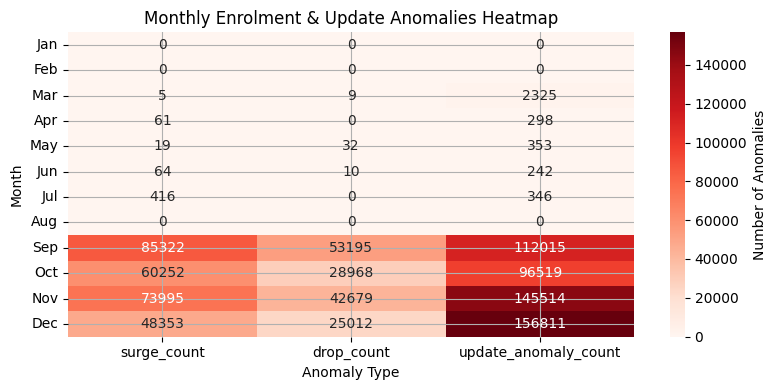

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = monthly_anomalies.set_index("month_label")[["surge_count", "drop_count", "update_anomaly_count"]]
plt.figure(figsize=(8,4))
sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="Reds", cbar_kws={"label": "Number of Anomalies"})
plt.title("Monthly Enrolment & Update Anomalies Heatmap")
plt.ylabel("Month")
plt.xlabel("Anomaly Type")
plt.tight_layout()
plt.show()

Pipeline for this

This section summarizes the findings from the cross-dataset analysis of Aadhaar enrolments,
demographic updates, and biometric updates. Insights are drawn from temporal trends, 
regional patterns, stress signals, and anomalies.

1. Dataset Overview
- All datasets are pre-cleaned and aligned at daily granularity.
- Advanced features include stress/volatility indicators for operational insights.
- Month, week, and quarter features allow temporal aggregation.

2. Enrolment vs Update Volume
- Monthly aggregation smooths noisy daily patterns.
- Enrolment and demographic updates generally follow similar trends.
- Biometric updates sometimes lag behind enrolment spikes, indicating operational bottlenecks.

 3. Regional Patterns
- Some districts show high enrolment but low updates → potential processing delays.
- Some districts have frequent updates with low enrolments → backlog correction.
- These patterns inform targeted resource allocation.


4. Temporal Lag Analysis
- Lag between enrolment peaks and update peaks observed in high-stress months.
- Identifying these lags helps predict operational pressure periods.

5. Stress & Imbalance Insights
- Enrolment stress (volatility) and update stress (bio-demo stress ratio) highlight overload periods.
- High-stress months may correspond to holidays, policy changes, or sudden surge/drop events.
- Proactive scaling of resources can mitigate operational stress.

6. Anomaly Detection
- Daily anomalies aggregated monthly show surge, drop, or high update stress months.
- Tables or heatmaps present anomalies clearly, avoiding confusion from overplotting.
- Enables quick identification of months needing further investigation.

7. Operational Implications
- Cross-dataset insights indicate months and regions under operational stress.
- Can guide:
  - Staffing/resource planning
  - Infrastructure scaling (biometric systems, update pipelines)
  - Policy review for enrolment-update alignment
  - Monitoring frameworks for early detection of surges/drops



In [ ]:
regional_summary = enrol_df.groupby("state_clean", as_index=False).sum(numeric_only=True)[["state_clean", "total_enrolments"]]

regional_demo = demo_df.groupby("state_clean", as_index=False).sum(numeric_only=True)[["state_clean", "total_demographic_updates"]]
regional_bio = bio_df.groupby("state_clean", as_index=False).sum(numeric_only=True)[["state_clean", "total_biometric_updates"]]

regional_summary = regional_summary.merge(regional_demo, on="state_clean", how="left")
regional_summary = regional_summary.merge(regional_bio, on="state_clean", how="left")

adv_enrol_state = adv_enrol_df.groupby("state_clean", as_index=False)["enrolment_volatility"].mean()
adv_demo_bio_state = adv_demo_bio_df.groupby("state_clean", as_index=False)["bio_demo_stress_ratio"].mean()

regional_summary = regional_summary.merge(adv_enrol_state, on="state_clean", how="left")
regional_summary = regional_summary.merge(adv_demo_bio_state, on="state_clean", how="left")

regional_summary.head()


,state_clean,total_enrolments,total_demographic_updates,total_biometric_updates,enrolment_volatility,bio_demo_stress_ratio
0,Andaman and Nicobar Islands,173,7246.0,20698.0,0.291614,2.596689
1,Andhra Pradesh,41948,2295582.0,3714633.0,0.457206,1.566578
2,Arunachal Pradesh,2027,36443.0,72394.0,0.564429,2.188209
3,Assam,145039,1012578.0,982722.0,0.669259,1.133823
4,Bihar,302969,4814350.0,4897587.0,0.653026,0.779918


In [ ]:
enrol_monthly_vol.to_csv("dashboard_enrolment_monthly.csv", index=False)
update_monthly_vol.to_csv("dashboard_update_monthly.csv", index=False)
monthly_anomalies.to_csv("dashboard_monthly_anomalies.csv", index=False)
regional_summary.to_csv("dashboard_regional_summary.csv", index=False) 